# Model selection 
Select the predicitons tools, scores and settings that best can predicit anti-drug antibodies (ADA) for 218 antibodies.\
Computation of the scores are made in the script "compute_scores" and then imported directly


In [27]:
# load libaries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm 
from scipy.stats import pearsonr, spearmanr

In [5]:
# Load table with all computed scores for all tools
computed_scors_biophi = pd.read_csv("all_predictors_217AB(biophidata).csv")
computed_scors_biophi.head()   

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.229277,94.757871,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,9.043928,95.568972,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,9.043928,96.271372,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,9.130060,96.304235,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.665805,96.583658,0.095804,31.544048,39,0.924883,0.835681


# Scatterplot ADA against all 15 predictors

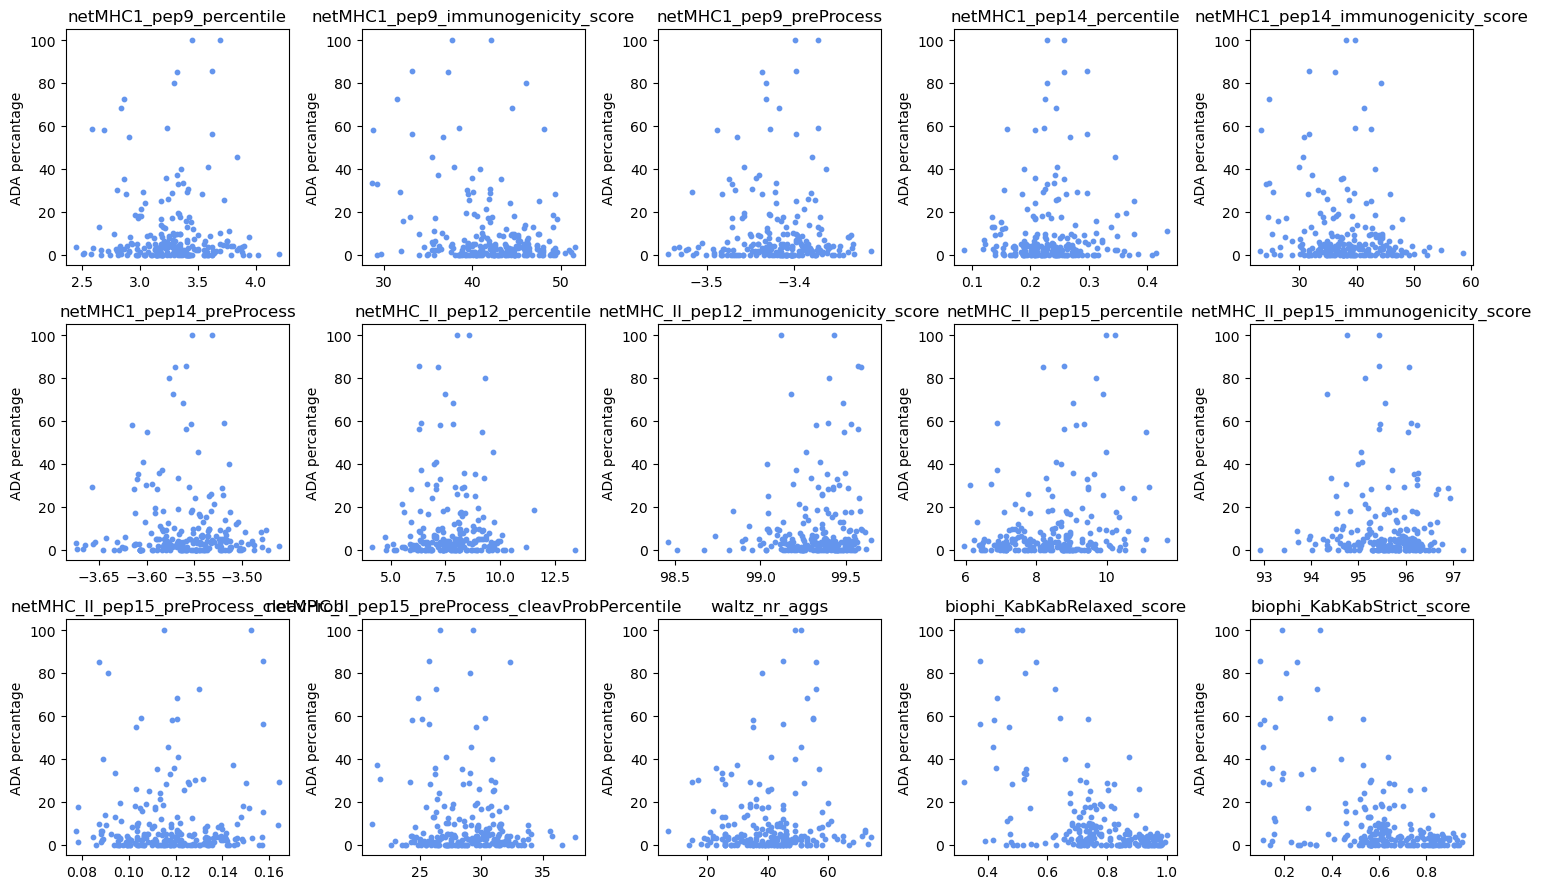

In [6]:
# for loop for all columns, make a scatter plot for each predictor against ADA

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(2, 17):
    ax = axes[i - 2]
    
    y = computed_scors_biophi['ADA_percentage']
    x = computed_scors_biophi.iloc[:, i]
    
    ax.scatter(x, y, s=10, c="cornflowerblue")
    ax.set_title(computed_scors_biophi.columns[i])
    ax.set_ylabel('ADA percantage')

plt.tight_layout()
plt.show()

# Correlation matrix

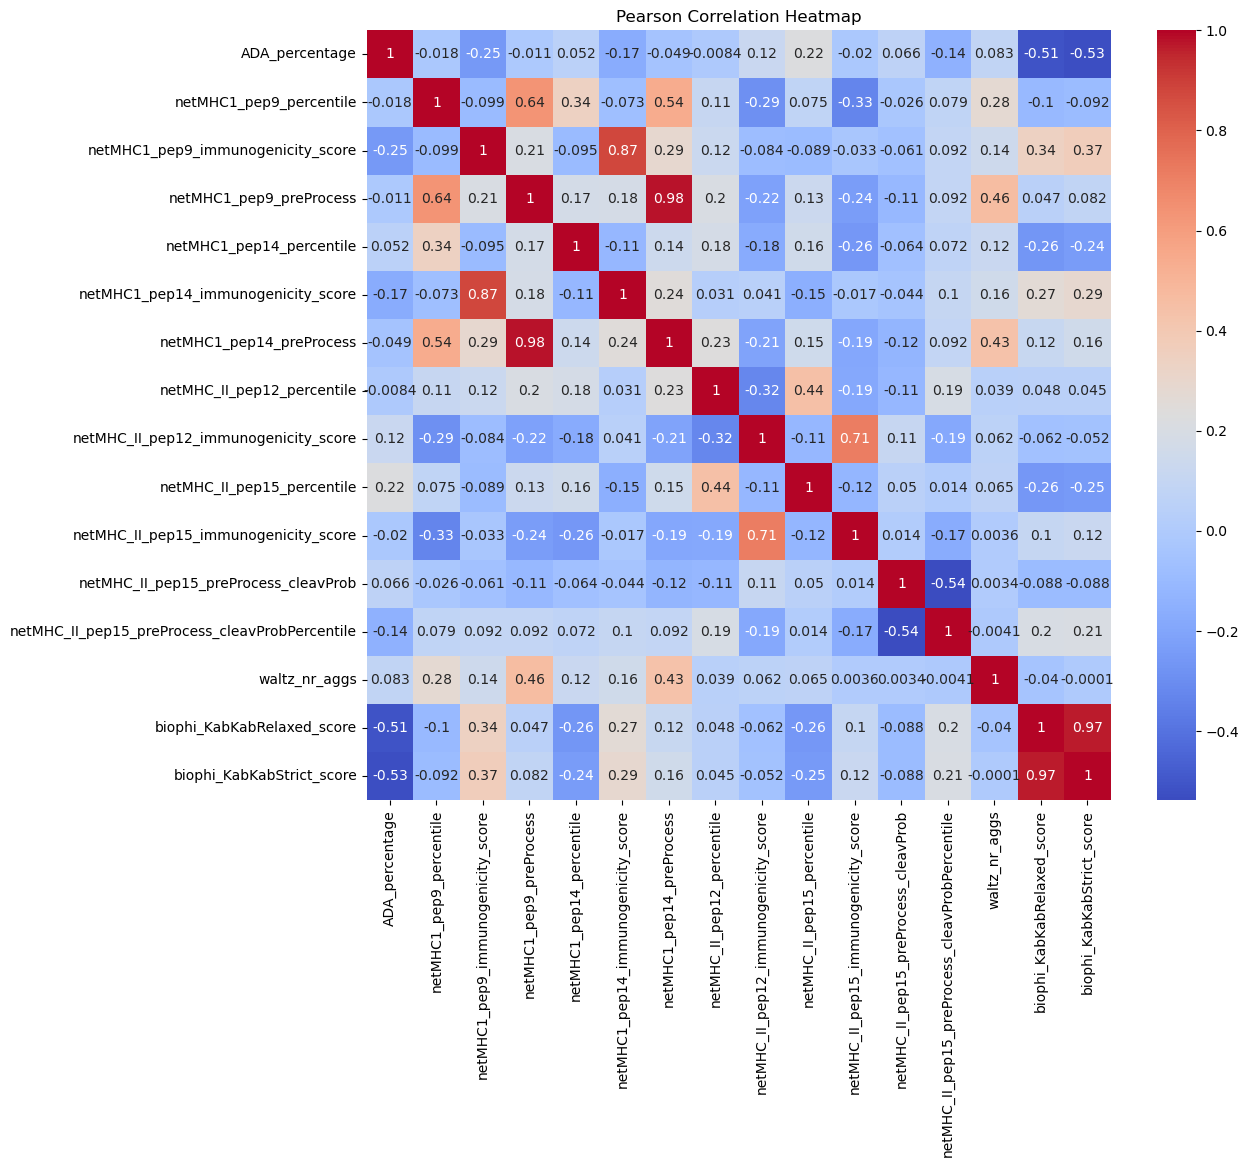

In [7]:
# First create a df without the antibody name and ADA percantage
ADA_corrtest = computed_scors_biophi.drop(columns=['antibody'])
pearson_corr = ADA_corrtest.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

In [8]:
# Compute Pearson correlation for all scores against ADA, and the p values
r, p = pearsonr(computed_scors_biophi['ADA_percentage'], computed_scors_biophi['netMHC1_pep9_percentile'])

print("Pearson r:", r)
print("p-value:", p)

Pearson r: -0.017922896142684185
p-value: 0.7924518109632331


In [9]:

results = []

for col in computed_scors_biophi.columns[2:17]:  # index 2 to 16 inclusive
    sub_df = computed_scors_biophi[['ADA_percentage', col]]
    
    if len(sub_df) > 1:
        pearson_r, pearson_pval = pearsonr(sub_df['ADA_percentage'], sub_df[col])
        spearman_r, spearman_pval = spearmanr(sub_df['ADA_percentage'], sub_df[col])
        
        results.append({
            'variable': col,
            'pearson_r': pearson_r,
            'pearson_pval': pearson_pval,
            'spearman_r': spearman_r,
            'spearman_p': spearman_pval
        })

# Convert to DataFrame
corr_results_df = pd.DataFrame(results)


In [10]:
corr_results_df

,variable,pearson_r,pearson_pval,spearman_r,spearman_p
0,netMHC1_pep9_percentile,-0.017923,7.924518e-01,-0.008049,9.059434e-01
1,netMHC1_pep9_immunogenicity_score,-0.253633,1.534562e-04,-0.154292,2.268729e-02
2,netMHC1_pep9_preProcess,-0.010767,8.744017e-01,0.009123,8.934616e-01
3,netMHC1_pep14_percentile,0.051819,4.465335e-01,0.027923,6.818163e-01
4,netMHC1_pep14_immunogenicity_score,-0.167915,1.304151e-02,-0.129923,5.544233e-02
5,netMHC1_pep14_preProcess,-0.048743,4.740104e-01,-0.002777,9.674838e-01
6,netMHC_II_pep12_percentile,-0.008371,9.021999e-01,0.038162,5.751968e-01
7,netMHC_II_pep12_immunogenicity_score,0.119333,7.873147e-02,0.067876,3.184921e-01
8,netMHC_II_pep15_percentile,0.223118,9.090138e-04,0.150861,2.592050e-02
9,netMHC_II_pep15_immunogenicity_score,-0.020461,7.638710e-01,-0.046945,4.904935e-01


In [11]:
# print the correlation of the ADA percentage column
pearson_corr['ADA_percentage'].sort_values(ascending=False)

ADA_percentage                                    1.000000
netMHC_II_pep15_percentile                        0.223118
netMHC_II_pep12_immunogenicity_score              0.119333
waltz_nr_aggs                                     0.083257
netMHC_II_pep15_preProcess_cleavProb              0.065528
netMHC1_pep14_percentile                          0.051819
netMHC_II_pep12_percentile                       -0.008371
netMHC1_pep9_preProcess                          -0.010767
netMHC1_pep9_percentile                          -0.017923
netMHC_II_pep15_immunogenicity_score             -0.020461
netMHC1_pep14_preProcess                         -0.048743
netMHC_II_pep15_preProcess_cleavProbPercentile   -0.142347
netMHC1_pep14_immunogenicity_score               -0.167915
netMHC1_pep9_immunogenicity_score                -0.253633
biophi_KabKabRelaxed_score                       -0.508176
biophi_KabKabStrict_score                        -0.528191
Name: ADA_percentage, dtype: float64

# Lasso regression

In [12]:
computed_scors_biophi

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.229277,94.757871,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,9.043928,95.568972,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,9.043928,96.271372,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,9.130060,96.304235,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.665805,96.583658,0.095804,31.544048,39,0.924883,0.835681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,zalutumumab,0.0,3.191138,42.410714,-3.394748,0.219855,38.356164,-3.521994,6.584362,99.248820,7.744108,95.617020,0.117738,25.100465,42,0.930556,0.805556
214,zolbetuximab,0.0,3.039362,39.461883,-3.458596,0.220863,36.238532,-3.593007,6.649832,99.524084,9.090909,96.301316,0.111857,27.603953,44,0.562791,0.334884
215,zolimomab,85.7,3.618365,33.179724,-3.398370,0.296995,31.603774,-3.558859,6.287683,99.571700,8.785530,95.436142,0.157254,25.740732,45,0.373206,0.095694
216,moab_81c6,100.0,3.686945,42.081448,-3.399031,0.257202,39.814815,-3.552895,8.585859,99.434207,9.991387,95.444688,0.152478,26.621190,49,0.516432,0.352113


In [28]:
# Create feature variables
X_all_features = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage']) # all except the response variable and the antibody names
y = computed_scors_biophi['ADA_percentage'] # the response varibale

# split data into training and test set
X_all_features_train, X_all_features_test, y_all_features_train, y_all_features_test = train_test_split(X_all_features, 
                                                                                                        y, test_size=0.2, random_state=12)

model1 = make_pipeline(
    StandardScaler(), # normalize the data
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model1.fit(X_all_features_train, y_all_features_train)

# Make and save a prediciton
y_all_features_pred = model1.predict(X_all_features_test)

# coefficients
coef = model1.named_steps['lassocv'].coef_

selected_features = X_all_features_train.columns[coef != 0]

# print the features that Lasso "decided" are the best once to use for the prediction
print(selected_features)

print(f'R^2: {model1.score(X_all_features_train, y_all_features_train)}')

Index(['netMHC1_pep9_immunogenicity_score',
       'netMHC_II_pep12_immunogenicity_score', 'netMHC_II_pep15_percentile',
       'netMHC_II_pep15_preProcess_cleavProb',
       'netMHC_II_pep15_preProcess_cleavProbPercentile', 'waltz_nr_aggs',
       'biophi_KabKabRelaxed_score', 'biophi_KabKabStrict_score'],
      dtype='object')
R^2: 0.329425065303113


In [33]:
print("Best alpha:", model1.named_steps['lassocv'].alpha_)

Best alpha: 0.6979247188278733


In [ ]:
# Lasso regression without the biophi score, since the biophi tool does not accept minibinders as input
X_no_biophi = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage', 'biophi_KabKabStrict_score', 'biophi_KabKabRelaxed_score']) 
y = computed_scors_biophi['ADA_percentage'] # the response varibale

# split data into training and test set
X_no_biophi_train, X_no_biophi_test, y_no_biophi_train, y_no_biophi_test = train_test_split(X_no_biophi, y, test_size=0.2, random_state=12)


model2 = make_pipeline(
    StandardScaler(), # normalize the data
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model2.fit(X_no_biophi_train, y_no_biophi_train)

# Make and save a prediciton
y_no_biophi_pred = model2.predict(X_no_biophi_test)

# coefficients
coef = model2.named_steps['lassocv'].coef_

selected_features = X_no_biophi.columns[coef != 0]

# print the features that Lasso "decided" are the best once to use for the prediction
print(selected_features)

print(f'R^2: {model2.score(X_no_biophi_train, y_no_biophi_train)}')

Index(['netMHC1_pep9_immunogenicity_score', 'netMHC_II_pep15_percentile'], dtype='object')
R^2: 0.07748447778814838


In [32]:
# Lasso regression without the biophi score, and with only deafult settings for the netMHC tools.
# Because having a model scores genereated from different settings means that one has to do 2 prediction-runs instead of one
# Lasso regression without the biophi score, since the biophi tool does not accept minibinders as input
X_only_default_settings = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage', 
                                                              'biophi_KabKabStrict_score', 'biophi_KabKabRelaxed_score',
                                                              'netMHC1_pep14_percentile', 'netMHC1_pep14_immunogenicity_score',
                                                              'netMHC1_pep14_preProcess',
                                                              'netMHC_II_pep12_percentile', 'netMHC_II_pep12_immunogenicity_score'
                                                              ]) 
y = computed_scors_biophi['ADA_percentage'] # the response varibale

# split data into training and test set
X_only_default_settings_train, X_only_default_settings_test, y_only_default_settings_train, y_only_default_settings_test = train_test_split(X_only_default_settings, 
                                                                                                        y, test_size=0.2, random_state=12)

model3 = make_pipeline(
    StandardScaler(), # normalize the data
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model3.fit(X_only_default_settings_train, y_only_default_settings_train)

# Make and save a prediciton
y_only_default_settings_pred = model3.predict(X_only_default_settings_test)

# coefficients
coef = model3.named_steps['lassocv'].coef_

selected_features = X_only_default_settings_train.columns[coef != 0]

# print the features that Lasso "decided" are the best once to use for the prediction
print(selected_features)

print(f'R^2: {model3.score(X_only_default_settings_train, y_only_default_settings_train)}')

Index(['netMHC1_pep9_immunogenicity_score', 'netMHC_II_pep15_percentile',
       'netMHC_II_pep15_preProcess_cleavProbPercentile', 'waltz_nr_aggs'],
      dtype='object')
R^2: 0.1656853032186698


# Visualization of results

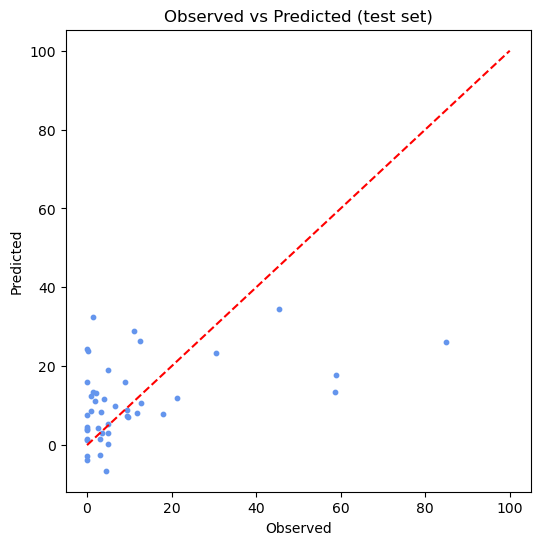

In [34]:
# Visualizaton model 1

plt.figure(figsize=(6,6))
plt.scatter(y_all_features_test, y_all_features_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

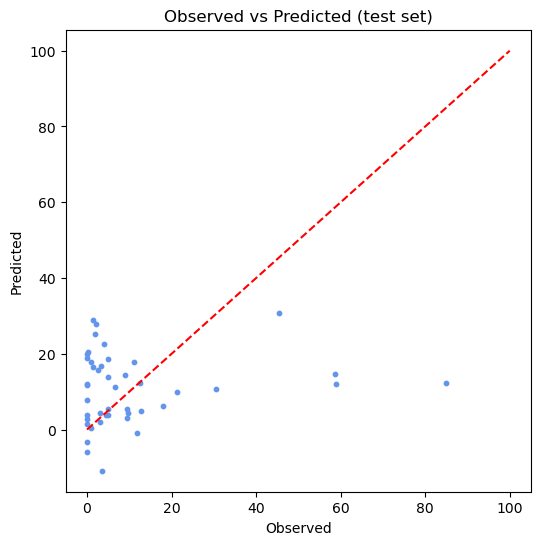

In [35]:
# Visualizaton model 2

plt.figure(figsize=(6,6))
plt.scatter(y_no_biophi_test, y_no_biophi_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

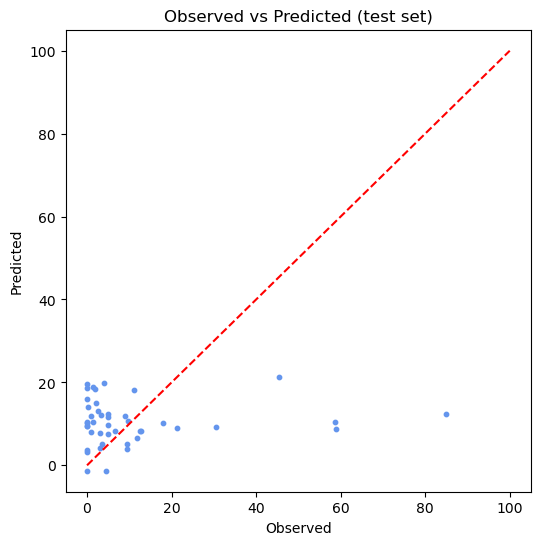

In [36]:
# Visualizaton model 3

plt.figure(figsize=(6,6))
plt.scatter(y_only_default_settings_test, y_only_default_settings_pred, s=10, c="cornflowerblue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted (test set)")
plt.show()

# Prediction on nanobodies